## Data Cleaning with Pandas 

In [1]:
import numpy as np
import pandas as pd

In [3]:
# Using a messy e-commerce store dataset for practice
df = pd.read_csv("data/messy_ecommerce_data.csv")
print(df.info()) # First check 'what your data is?'

<class 'pandas.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        664 non-null    str  
 1   customer_name   664 non-null    str  
 2   age             645 non-null    str  
 3   gender          654 non-null    str  
 4   city            653 non-null    str  
 5   order_date      664 non-null    str  
 6   product         664 non-null    str  
 7   category        664 non-null    str  
 8   unit_price      653 non-null    str  
 9   quantity        654 non-null    str  
 10  email           655 non-null    str  
 11  payment_method  656 non-null    str  
 12  status          664 non-null    str  
dtypes: str(13)
memory usage: 67.6 KB
None


In [4]:
# Checking missing values per column
print(df.isnull().sum())

order_id           0
customer_name      0
age               19
gender            10
city              11
order_date         0
product            0
category           0
unit_price        11
quantity          10
email              9
payment_method     8
status             0
dtype: int64


In [5]:
# Checking total null values
print(df.isnull().sum().sum())

78


In [6]:
# First copy the original DataFrame
df2 = df.copy()
# calculating the missing data percentage per column
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))

age               2.861446
city              1.656627
unit_price        1.656627
quantity          1.506024
gender            1.506024
email             1.355422
payment_method    1.204819
customer_name     0.000000
order_id          0.000000
category          0.000000
product           0.000000
order_date        0.000000
status            0.000000
dtype: float64


## Handling Missing Data: dropna() vs. Filling

From our missing-value check above, every column has less than 5% missing data. 
Based on the rule of thumb — *"if missing data is under 5% and appears random, 
dropping rows is usually safe"* — a natural question arises:

> **Should we simply use `dropna()` here and move on?**

Let's explore what that would actually look like, and why it isn't always 
the best choice — even when the rule technically allows it.

### Option 1: `df.dropna()`

This removes **any row that has a missing value in *any* column** — even if 
just one field out of thirteen is empty. It's the simplest option, but also 
the most aggressive: a single missing `email` could cost you an otherwise 
perfectly good row of sales data.

In [7]:
df3 = df2.dropna() 
print(df3.isnull().sum())

order_id          0
customer_name     0
age               0
gender            0
city              0
order_date        0
product           0
category          0
unit_price        0
quantity          0
email             0
payment_method    0
status            0
dtype: int64


### Option 2: `df.dropna(subset=[...])`

A more targeted version — this only drops rows where *specific* columns are 
missing, leaving the rest of the row intact even if other columns have gaps. 
More precise than the blanket approach above, but still throws away real data 
that could otherwise be recovered.

In [8]:
# Droping the Null Values of a specific column 
df4 = df2.dropna(subset = ['age']) # we can pass multiple columns in the list
print(df4.isnull().sum()) # now all rows in which column 'age' had null values are dropped 

order_id           0
customer_name      0
age                0
gender             9
city              11
order_date         0
product            0
category           0
unit_price        10
quantity          10
email              9
payment_method     8
status             0
dtype: int64


### Our Approach: Clean & Fill, Not Drop

Although the "under 5%" rule would technically justify dropping rows here, 
this is a **small, focused dataset** — every row carries meaningful value, 
and dropping data early would undermine the purpose of demonstrating 
proper cleaning logic.

Instead, for each column we'll:
1. Investigate *why* values are missing or malformed
2. Clean formatting and fix invalid entries
3. Fill missing values using a reasoned, column-appropriate strategy 
   (median, mode, "Unknown", or context-based imputation)

This reflects how real-world datasets are typically handled — where each 
row represents meaningful information, and dropping data without 
justification isn't a responsible option.

count     645
unique     52
top        54
freq       26
Name: age, dtype: object
Axes(0.125,0.11;0.775x0.77)


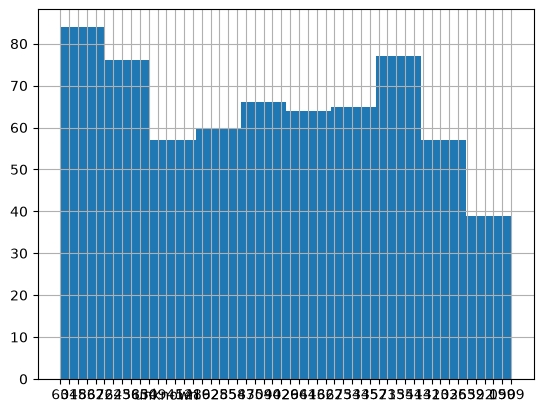

In [9]:
# let's start with 'age' column
print(df2['age'].describe())
print(df2['age'].hist())

In [10]:
# The above results show that age is str but it should be numeric
df2['age'].unique()

<StringArray>
[     '60',      '34',      '18',      '56',      '37',      '26',      '24',
      '25',      '38',      '63',      '50',      '49', 'unknown',      '41',
      '52',      '48',      '19',      '62',      '28',      '55',      '58',
      '47',      '30',      '59',      '40',      '42',      '29',      '64',
      '61',      '46',      '36',      '27',      '23',      '53',      '43',
      '45',       nan,      '57',      '21',      '33',      '54',      '51',
      '44',      '31',      '20',      '32',      '35',      '65',      '39',
      '22',       '0',     '150',     '999']
Length: 53, dtype: str

In [11]:
# Note in 'age' column there is a string "unknown" and outliers like 0, 150 and 999 which are impossible values for age
# let first convert the datatype
df2['age'] = pd.to_numeric(df['age'], errors='coerce')
df2['age'].unique()

array([ 60.,  34.,  18.,  56.,  37.,  26.,  24.,  25.,  38.,  63.,  50.,
        49.,  nan,  41.,  52.,  48.,  19.,  62.,  28.,  55.,  58.,  47.,
        30.,  59.,  40.,  42.,  29.,  64.,  61.,  46.,  36.,  27.,  23.,
        53.,  43.,  45.,  57.,  21.,  33.,  54.,  51.,  44.,  31.,  20.,
        32.,  35.,  65.,  39.,  22.,   0., 150., 999.])

In [12]:
# Now handling 0,150,999
# from above values, the valid range (in case of this dataset) seems to be between [18,70] 
# So, replacing those unusual values with NaN
df2.loc[(df2['age'] < 18) | (df2['age'] > 70), 'age'] = np.nan
df2['age'].info()

<class 'pandas.Series'>
RangeIndex: 664 entries, 0 to 663
Series name: age
Non-Null Count  Dtype  
--------------  -----  
640 non-null    float64
dtypes: float64(1)
memory usage: 5.3 KB


In [13]:
# Again calculate the missing percentage for 'age' column
print(df2['age'].isnull().sum() / len(df2['age']) * 100) # a total of 24 values are missing

3.614457831325301


Mean:  41.48125
Median:  42.0


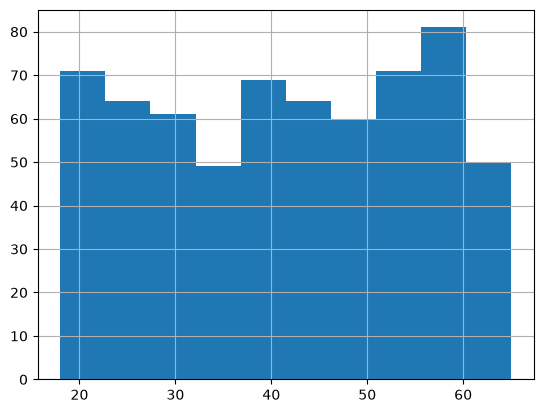

In [14]:
df2['age'].hist()
print("Mean: ", df2['age'].mean())
print("Median: ", df2['age'].median())

In [15]:
# Now we can fill those NaN values with median
# Why median and not mean?
# Although data distribution is roughly symmetric, mean and median will be close to each other, so either works (in this case)
# But "Median" is till the safer default for real-world data since it's i=not affected by any outliers
df2['age'] = df2['age'].fillna(df2['age'].median())
print(df2['age'].isnull().sum()) # Yay! column 'age' is now fully cleaned

0


In [16]:
# Now let's clean "unit_price" as it is core business data
df2['unit_price'].unique()

<StringArray>
[     '9238.84',     '11754.36',     '44713.92', 'PKR 4,363.75',
     '41632.93',       '3029.1',     '12629.17',       '70,899',
     '39706.52',    '154602.08',
 ...
    '133163.67',     '57346.24',     '39366.11',     '83987.73',
      '4938.14',     '38488.85',     '11362.13',     '13064.96',
     '56048.07',      '2135.89']
Length: 641, dtype: str

In [17]:
# But as there are 641 unique values and all are not visible but we want to catch all those values which don't match the normal number pattern
# using regex
mask = ~df2['unit_price'].str.match(r'^\d+(\.\d+)?$')
print(df2.loc[mask,'unit_price'].unique())

<StringArray>
[ 'PKR 4,363.75',        '70,899',    'Rs. 11,767',        '33,342',
    'Rs. 46,700',    '$39,289.68',         '4,370',  'PKR 2,267.56',
         '2,616',    'Rs. 35,174',             nan,        '35,395',
    '$75,746.16',         '2,077',         '8,074', 'PKR 56,981.66',
     'Rs. 3,121',         '2,047',     'Rs. 8,806',        '53,640',
    '$11,574.95',          'free',    'Rs. 44,014',     '$2,783.76',
   '$137,178.24',     '$2,937.38',    '$83,991.01',  'PKR 4,945.12',
     '$4,189.51',    'Rs. 40,738',  'PKR 4,844.18',       'unknown',
   '$161,499.85',  'PKR 4,601.23',  'PKR 8,473.09',        '33,927',
          '-500',         '8,502',     '$2,565.61',        '45,458']
Length: 40, dtype: str


In [18]:
# A lot of mess from above results like currency symbols, 'unknown', 'free', '-500'
# Step 1: let first clean the formatting _removing currency symbols & commas
df2['unit_price'] = df2['unit_price'].str.replace(r'[^\d.]', '', regex=True)

In [19]:
print(df2['unit_price'].unique())

<StringArray>
[  '9238.84',  '11754.36',  '44713.92',   '4363.75',  '41632.93',    '3029.1',
  '12629.17',     '70899',  '39706.52', '154602.08',
 ...
 '133163.67',  '57346.24',  '39366.11',  '83987.73',   '4938.14',  '38488.85',
  '11362.13',  '13064.96',  '56048.07',   '2135.89']
Length: 640, dtype: str


In [20]:
# Step 2: Now convertig them to numeric
df2['unit_price'] = pd.to_numeric(df2['unit_price'], errors='coerce')
print(df2['unit_price'].isnull().sum())

14


In [21]:
# step 3: Handling 'free'
# although 'free' has been converted to  NaN but we can catch it using original dataFrame that is 'df'
# What could 'free' mean?
# 'free' seems to be a 'promo item' because nobody will write 'free' for something he had paid for. So, we can replace free with 0
mask_free = df['unit_price'] == 'free'
df2.loc[mask_free, 'unit_price'] = 0

In [22]:
# Now checking
print(df2['unit_price'].isnull().sum())

13


In [23]:
# Step 4: Handling 'unknown'
# 'unknown' means price wasn't recorded _ but let's check if it relates to other columns (category, product, status) 
# before deciding how to treat it
mask_unknown = df['unit_price'] == 'unknown' # again using original data frame
df[mask_unknown][['category', 'product', 'status']]

,category,product,status
545,Storage,USB Drive,Pending
604,Accessories,Smart Watch,Cancelled


In [24]:
# 'unknown' rows: both are non-completed orders (Pending/Cancelled) — 
# suggests price wasn't finalized. But only 2 rows, so this is a weak signal,
# not a confirmed pattern. Treating as genuine missing data (stays NaN),
# to be filled later along with other missing unit_price values.
# But... Instead of filling 'unknown' with the overall column median,
# use group-based imputation — fill using the median price of the SAME
# product (USB Drive / Smart Watch), since price varies a lot by product.
# This gives a more realistic estimate than a single blanket median.
usb_median = df2[df2['product'] == 'USB Drive']['unit_price'].median()
watch_median = df2[df2['product'] == 'Smart Watch']['unit_price'].median()

df2.loc[mask_unknown & (df['product'] == 'USB Drive'), 'unit_price'] = usb_median
df2.loc[mask_unknown & (df['product'] == 'Smart Watch'), 'unit_price'] = watch_median
print(df2['unit_price'].isna().sum())

11


In [25]:
# Filling remaining genuine NaN unit_price values using group-based median (per product),
# same logic as the 'unknown' fix — but using transform() since there are many more
# product types here than just 2, so per-product manual lines aren't practical.

product_medians = df2.groupby('product')['unit_price'].transform('median')
df2['unit_price'] = df2['unit_price'].fillna(product_medians)

print(df2['unit_price'].isna().sum())

1


In [26]:
print(df2[df2['unit_price'].isna()])

      order_id customer_name   age gender      city  order_date     product  \
551  ORD-10158    Sana Nawaz  56.0   Male  Peshawar  2025-05-26  smartphone   

        category  unit_price quantity                   email payment_method  \
551  Electronics         NaN        1  sana.nawaz59@gmail.com  Bank Transfer   

      status  
551  Pending  


In [27]:
# Note: This row remained NaN because 'product' casing wasn't standardized
# before the group-based median fill. 'smartphone' (lowercase) was treated
# as a separate group from 'Smartphone', leaving this row as the sole member
# of its group — with its own price already missing, the group median was NaN.
# Lesson: categorical columns must be cleaned/standardized BEFORE
# being used as a groupby key, or inconsistent casing silently fragments
# what should be a single group.
df2['product'] = df2['product'].str.strip().str.title()

# Then re-run the group-based median fill
product_medians = df2.groupby('product')['unit_price'].transform('median')
df2['unit_price'] = df2['unit_price'].fillna(product_medians)

print(df2['unit_price'].isna().sum())

0


In [28]:
# Now, let's clean "city" column
print(df2['city'].unique())

<StringArray>
[ 'Islamabad',    'Sialkot',     'Multan', 'Rawalpindi',   'Peshawar',
 'Faisalabad',     'Lahore',    'Karachi', 'Gujranwala',    'KARACHI',
     'Quetta',   'PESHAWAR',          nan,     'lahore',    'karachi',
  'islamabad', 'faisalabad',  'ISLAMABAD',     'MULTAN',    'sialkot',
 'GUJRANWALA',     'QUETTA',     'multan',     'LAHORE', 'FAISALABAD',
   'peshawar',     'quetta', 'RAWALPINDI']
Length: 28, dtype: str


In [29]:
# It is good to strip () first in case of any stray spaces and then clean the format using .title()
df2['city'] = df2['city'].str.strip().str.title()
print(df2['city'].unique())

<StringArray>
[ 'Islamabad',    'Sialkot',     'Multan', 'Rawalpindi',   'Peshawar',
 'Faisalabad',     'Lahore',    'Karachi', 'Gujranwala',     'Quetta',
          nan]
Length: 11, dtype: str


In [30]:
# Handling missing 'city' values:
# Unlike age/price, city doesn't have a natural "typical" value to estimate —
# filling with the mode would arbitrarily assign one city to all missing rows.
# Since missing % is very small (1.66%), filling with "Unknown" is more honest
# than guessing, and keeps the real city distribution undistorted.
df2['city'] = df2['city'].fillna('Unknown')
df2['city'].isna().sum()

np.int64(0)

In [31]:
# Cleaning 'gender' column
print(df2['gender'].unique())

<StringArray>
['Male', 'Female', 'MALE', nan, 'FEMALE', 'male', 'F', 'female', 'M']
Length: 9, dtype: str


In [32]:
# Handling formatting
df2['gender'] = df2['gender'].str.capitalize()
F_mask = df2['gender'] == 'F' 
M_mask = df2['gender'] == 'M'
df2.loc[F_mask, 'gender'] = "Female"
df2.loc[M_mask, 'gender'] ="Male"
print(df2['gender'].unique())

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str


In [33]:
# Handling missing 'gender' values:
# With only 2 categories, mode-fill would essentially guess for 10 real
# people based on which category is slightly more common — not a genuine
# estimate like age/price. Filling with "Unknown" avoids injecting bias
# into a demographic field.
df2['gender'] = df2['gender'].fillna('Unknown')
df2['gender'].isna().sum()

np.int64(0)

In [34]:
# Cleaning 'quantity'
print(df2['quantity'].unique())

<StringArray>
['1', '4', '3', '2', '5', nan, '100', 'two', '0']
Length: 9, dtype: str


<Axes: >

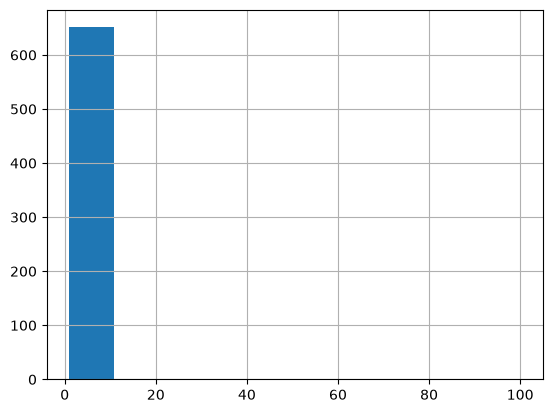

In [35]:
df2.loc[df2['quantity'] == 'two', 'quantity'] = '2'
df2['quantity'] = pd.to_numeric(df2['quantity'], errors='coerce')
df2.loc[df2['quantity'] == 0, 'quantity'] = np.nan
df2['quantity'].hist()

In [36]:
df2['quantity'].describe()

count    652.000000
mean       1.917178
std        3.975642
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      100.000000
Name: quantity, dtype: float64

In [37]:
# from above all info "100" quantity seems to be an outlier
print(df2['quantity'].unique())
print(df2.loc[df2['quantity'] == 100][['quantity','unit_price','payment_method','status','product']]) 
#checking other columns (specially unit_price} shows that 100 is an outlier for sure

[  1.   4.   3.   2.   5.  nan 100.]
    quantity  unit_price payment_method     status product
72     100.0    48782.49  Bank Transfer  Cancelled  Tablet


In [38]:
df2.loc[df2['quantity'] == 100, 'quantity'] = np.nan
df2['quantity'].isna().sum()

np.int64(13)

count    651.000000
mean       1.766513
std        1.003463
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: quantity, dtype: float64

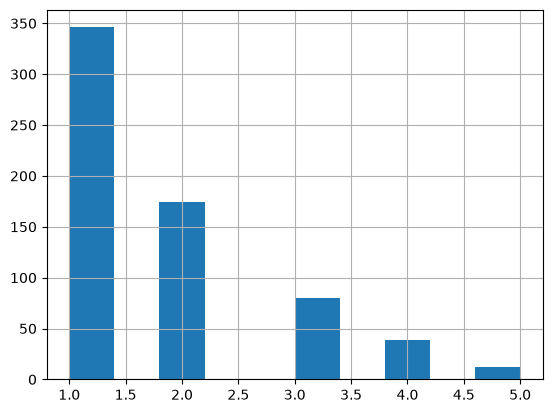

In [39]:
df2['quantity'].hist()
df2['quantity'].describe()

In [40]:
# Filling missing 'quantity' with median (right-skewed distribution,
# most orders are 1-5 items, so median reflects the typical order size
# better than mean, which is pulled up by outliers).
# Converting back to int since quantity can't logically be a fraction —
# it was float only because NaN forced it during cleaning.
df2['quantity'] = df2['quantity'].fillna(df2['quantity'].median())
df2['quantity'] = df2['quantity'].astype(int)
print(df2['quantity'].isnull().sum())

0


In [41]:
# Cleaning 'email'
print(df2['email'].unique()[:20]) # just a peak not all 641
df2['email'].isnull().sum()

<StringArray>
[   'maham.raza29@gmail.com',  'maham.sheikh17@gmail.com',
  'hamza.sheikh90@gmail.com',   'ahmed.ahmed33@gmail.com',
     'hina.butt42@gmail.com',   'hassan.butt80@gmail.com',
    'maham.khan98@gmail.com',   'hassan.butt89@gmail.com',
   'fatima.butt74@gmail.com',     'sara.butt61@gmail.com',
    'talha.butt81@gmail.com',  'ayesha.malik82@gmail.com',
    'iqra.nawaz36@gmail.com',   'ahmed.malik74@gmail.com',
     'iqra.khan38@gmail.com',    'ahmed.butt16@gmail.com',
 'hassan.sheikh82@gmail.com',  'danish.ahmed53@gmail.com',
  'zainab.iqbal57@gmail.com',   'hassan.raza90@gmail.com']
Length: 20, dtype: str


np.int64(9)

In [42]:
# Above check is not enough for catching messy formats
# So, Find emails that don't match a standard email pattern
mask_bad_email = ~df2['email'].str.match(r'^[\w\.-]+@[\w\.-]+\.\w+$', na=False)
df2.loc[mask_bad_email, 'email'].unique()

<StringArray>
[nan, 'user@', 'unknown', 'test.com', 'missing-at-domain.com', 'abc@gmail']
Length: 6, dtype: str

In [43]:
# 'email' cleanup:
# Genuine NaNs (never provided) and garbage/placeholder values ('user@',
# 'test.com', 'unknown', etc. — caught via regex mismatch) both represent
# unusable email data. Since an email can't be estimated like a number,
# replacing both with "Unknown" is more honest than guessing.
df2.loc[mask_bad_email, 'email'] = 'Unknown'
df2['email'] = df2['email'].fillna('Unknown')
df2['email'].isna().sum()

np.int64(0)

In [44]:
# Cleaning 'payment_method'
print(df2['payment_method'].unique())

<StringArray>
[    'EasyPaisa', 'Bank Transfer',          'Cash',     'Jazz cash',
          'CARD',      'JazzCash',          'Card', 'BANK TRANSFER',
      'jazzcash',          'cash',             nan,          'CASH',
    'Easy paisa',          'card']
Length: 14, dtype: str


In [45]:
# Handling format
df2['payment_method'] = df2['payment_method'].str.strip().str.title()
print(df2['payment_method'].unique())

<StringArray>
[    'Easypaisa', 'Bank Transfer',          'Cash',     'Jazz Cash',
          'Card',      'Jazzcash',             nan,    'Easy Paisa']
Length: 8, dtype: str


In [46]:
# Handling multi word inconsistency
df2['payment_method'] = df2['payment_method'].replace({
    "Easypaisa" : 'EasyPaisa',
    'Easy Paisa' : 'EasyPaisa',
    'Jazz Cash' : 'JazzCash',
    'Jazzcash' : 'JazzCash'
})
print(df2['payment_method'].unique())

<StringArray>
['EasyPaisa', 'Bank Transfer', 'Cash', 'JazzCash', 'Card', nan]
Length: 6, dtype: str


In [47]:
# Handling NaN values
# Again we can't estimate the payment_method 
df2['payment_method'] = df2['payment_method'].fillna('unknown')
df2['payment_method'].isna().sum()

np.int64(0)

In [48]:
# Checking 'order_date' format
print(df2['order_date'].unique()[400:550])

<StringArray>
['2025-08-04', '2024-10-20', '2024-02-13', '2026-02-16', '2024-06-30',
 '2024-09-28', '2024-07-28', '2024-12-13', '2025-12-17', '2026-03-02',
 '2024-11-24', '2024-11-08', '2025-06-03', '2026-04-25', '2024-11-15',
 '2026-02-19', '2024-12-08', '2024-01-30', '2025-04-22', '2025-04-01',
 '2024-07-25', '2025-06-20', '2024-11-11', '2026-06-05', '2024-08-12',
 '2024-05-15', '2026-06-09', '2025-09-18', '2025-05-28', '2025-07-26',
 '2024-03-12', '2024-04-21', '2026-04-01', '2024-06-02', '2025-01-19',
 '2025-02-14', '2024-04-23', '2025-12-05', '2024-06-23', '2024-09-25',
 '2024-05-22', '2024-08-09', '2024-06-16', '2025-11-10', '2025-12-20',
 '2024-12-22', '2025-11-03', '2024-04-10', '2025-07-20', '2024-01-27',
 '2024-11-19', '2026-03-23', '2025-01-15', '2024-07-15', '2026-04-04',
 '2024-03-10', '2025-07-04', '2025-03-06', '2026-03-24', '2024-10-16',
 '2025-10-23', '2025-11-20', '2026-04-06', '2025-08-03', '2026-02-04',
 '2025-11-09', '2024-10-12', '2024-10-04', '2024-03-09', '2024-

In [49]:
# Formatting is correct (change the slicing and check yourself in above cell)
# Converting dtype from 'str' to actual pandas 'datetime'
df2['order_date'] = pd.to_datetime(df2['order_date'], errors='coerce')
df2['order_date'].isna().sum()

np.int64(0)

In [50]:
# Checking for duplicate rows
print(df2.duplicated().sum())

9


In [51]:
df2[df2.duplicated(keep=False)]

,order_id,customer_name,age,gender,city,order_date,product,category,unit_price,quantity,email,payment_method,status
18,ORD-10143,Zainab Iqbal,41.0,Female,Faisalabad,2024-06-11,Printer,Office,32300.63,1,zainab.iqbal57@gmail.com,EasyPaisa,Returned
75,ORD-10582,Danish Raza,27.0,Female,Rawalpindi,2024-08-17,Smart Watch,Accessories,13945.09,1,danish.raza88@gmail.com,EasyPaisa,Pending
77,ORD-10327,Zainab Nawaz,63.0,Female,Quetta,2024-01-29,Monitor,Electronics,42922.23,3,zainab.nawaz41@gmail.com,Bank Transfer,Pending
90,ORD-10474,Omar Butt,29.0,Female,Multan,2024-01-10,Headphones,Accessories,9316.44,1,omar.butt19@gmail.com,Card,Cancelled
95,ORD-10028,Hamza Butt,42.0,Female,Multan,2025-02-09,Monitor,Electronics,42551.53,1,hamza.butt86@gmail.com,JazzCash,Completed
123,ORD-10514,Hina Shah,56.0,Male,Quetta,2024-11-27,Tablet,Electronics,56707.77,3,hina.shah98@gmail.com,Bank Transfer,Pending
164,ORD-10028,Hamza Butt,42.0,Female,Multan,2025-02-09,Monitor,Electronics,42551.53,1,hamza.butt86@gmail.com,JazzCash,Completed
236,ORD-10143,Zainab Iqbal,41.0,Female,Faisalabad,2024-06-11,Printer,Office,32300.63,1,zainab.iqbal57@gmail.com,EasyPaisa,Returned
238,ORD-10514,Hina Shah,56.0,Male,Quetta,2024-11-27,Tablet,Electronics,56707.77,3,hina.shah98@gmail.com,Bank Transfer,Pending
256,ORD-10602,Maryam Sheikh,54.0,Female,Lahore,2026-01-14,Usb Drive,Storage,2114.84,2,maryam.sheikh5@gmail.com,EasyPaisa,Pending


In [52]:
# Removing exact duplicate rows (8 pairs = 16 rows, keeping first occurrence)
df2 = df2.drop_duplicates(keep='first')
print(df2.duplicated().sum())   # should be 0 now
print(df2.shape)                 # row count should drop by 8

0
(655, 13)


In [53]:
# Quick sanity check for remaining columns
for col in ['order_id', 'customer_name', 'product', 'category', 'status']:
    print(f"--- {col} ---")
    print(df2[col].unique()[:15])
    print("Missing:", df2[col].isnull().sum())
    print()

--- order_id ---
<StringArray>
['ORD-10537', 'ORD-10016', 'ORD-10620', 'ORD-10254', 'ORD-10527', 'ORD-10404',
 'ORD-10276', 'ORD-10336', 'ORD-10607', 'ORD-10108', 'ORD-10323', 'ORD-10033',
 'ORD-10468', 'ORD-10619', 'ORD-10417']
Length: 15, dtype: str
Missing: 0

--- customer_name ---
<StringArray>
[  'Maham Raza', 'Maham Sheikh', 'Hamza Sheikh',  'Ahmed Ahmed',
    'Hina Butt',  'Hassan Butt',   'Maham Khan',  'Fatima Butt',
    'Sara Butt',   'Talha Butt', 'Ayesha Malik',   'Iqra Nawaz',
  'Ahmed Malik',    'Iqra Khan',   'Ahmed Butt']
Length: 15, dtype: str
Missing: 0

--- product ---
<StringArray>
[ 'Headphones', 'Smart Watch',     'Monitor',    'Keyboard',       'Mouse',
  'Smartphone',      'Laptop',     'Printer',      'Tablet',   'Usb Drive']
Length: 10, dtype: str
Missing: 0

--- category ---
<StringArray>
['Accessories', 'Electronics', 'Office', 'Storage', 'electronics', 'Unknown']
Length: 6, dtype: str
Missing: 0

--- status ---
<StringArray>
[  'Pending',  'Returned', 'Canc

In [54]:
# Quick fixes
df2['customer_name'] = df2['customer_name'].str.strip().str.title()
# df2['product'] = df2['product'].str.strip().str.title() -> product formatting is already cleaned above
df2['category'] = df2['category'].str.strip().str.title()
df2['status'] = df2['status'].str.strip().str.title()
print(df2['order_id'].duplicated().sum())

5


In [55]:
dup_ids = df2[df2['order_id'].duplicated(keep=False)]
dup_ids.sort_values('order_id')

,order_id,customer_name,age,gender,city,order_date,product,category,unit_price,quantity,email,payment_method,status
263,ORD-10174,Maryam Sheikh,32.0,Male,Sialkot,2025-06-04,Headphones,Accessories,8074.00,2,maryam.sheikh92@gmail.com,Card,Pending
445,ORD-10174,Maryam Sheikh,32.0,Male,Sialkot,2025-06-04,Headphones,Accessories,8073.55,2,maryam.sheikh92@gmail.com,Card,Pending
250,ORD-10261,Fahad Shah,24.0,Male,Islamabad,2025-03-16,Monitor,Electronics,43482.67,4,ali@gmail.com,JazzCash,Pending
377,ORD-10261,Fahad Shah,24.0,Male,Islamabad,2025-03-16,Monitor,Electronics,43482.67,4,Unknown,JazzCash,Pending
45,ORD-10274,Fatima Malik,36.0,Male,Peshawar,2024-08-13,Laptop,Electronics,159632.37,2,fatima.malik73@gmail.com,Card,Cancelled
218,ORD-10274,Fatima Malik,36.0,Male,Faisalabad,2024-08-13,Laptop,Electronics,159632.37,2,fatima.malik73@gmail.com,Card,Cancelled
226,ORD-10280,Hamza Sheikh,38.0,Male,Gujranwala,2025-12-29,Headphones,Accessories,9138.13,1,hamza.sheikh90@gmail.com,EasyPaisa,Completed
311,ORD-10280,Hamza Sheikh,38.0,Male,Gujranwala,2025-12-29,Headphones,Accessories,9138.13,1,hamza.sheikh90@gmail.com,EasyPaisa,Pending
137,ORD-10308,Hassan Javed,19.0,Male,Peshawar,2025-02-23,Keyboard,Accessories,4369.73,1,hassan.javed98@gmail.com,JazzCash,Completed
150,ORD-10308,Hassan Javed,19.0,Male,Peshawar,2025-02-23,Keyboard,Accessories,4370.00,1,hassan.javed98@gmail.com,JazzCash,Completed


In [56]:

# Keep the row with 'Completed' status, drop the 'Pending' duplicate for ORD-10280
df2 = df2.drop(df2[(df2['order_id'] == 'ORD-10280') & (df2['status'] == 'Pending')].index)
# --- ORD-10174 (Maryam Sheikh): unit_price differs slightly (8074.00 vs 8073.55) ---
# Difference is negligible (~0.45), almost certainly a rounding/entry variation,
# not a meaningful conflict. Keeping the first occurrence is reasonable since
# neither value is more "trustworthy" than the other.
df2 = df2.drop(df2[(df2['order_id'] == 'ORD-10174') & (df2['unit_price'] == 8073.55)].index)
# --- ORD-10261 (Fahad Shah): email differs (ali@gmail.com vs 'Unknown') ---
# A real, specific email is strictly more informative than a placeholder like
# 'Unknown' — keeping the row with actual data preserves more usable information.
df2 = df2.drop(df2[(df2['order_id'] == 'ORD-10261') & (df2['email'] == 'Unknown')].index)
# --- ORD-10274 (Fatima Malik): city differs (Peshawar vs Faisalabad) ---
# Unlike status or email, there's no logical rule to determine which city is
# correct — both are equally plausible, genuine values, not one real vs one
# placeholder. This is a true unresolvable conflict, not a "which is better" call.
# Keeping the first occurrence, but flagging this explicitly rather than pretending
# the decision was principled — honesty about the limitation matters here.
df2 = df2.drop(df2[(df2['order_id'] == 'ORD-10274') & (df2['city'] == 'Faisalabad')].index)
# --- ORD-10308 (Hassan Javed): unit_price differs slightly (4369.73 vs 4370.00) ---
# Same reasoning as ORD-10174 — negligible rounding difference, no clear winner,
# keeping first occurrence is a reasonable default.
df2 = df2.drop(df2[(df2['order_id'] == 'ORD-10308') & (df2['unit_price'] == 4370.00)].index)
# Final check — confirm no order_id duplicates remain
print(df2['order_id'].duplicated().sum())


0


### Renaming a Column

In [57]:
# let's rename 'product' to 'product_name'
df2.rename(columns={'product' : 'product_name'}, inplace=True)
# without inplace=True .rename() will return a new DataFrame without touching the original
print(df2.columns)
# We can also clean column names in one line
df2.columns = df2.columns.str.strip().str.lower().str.replace(' ','_') 

Index(['order_id', 'customer_name', 'age', 'gender', 'city', 'order_date',
       'product_name', 'category', 'unit_price', 'quantity', 'email',
       'payment_method', 'status'],
      dtype='str')


### Saving Cleaned Data to a CSV File

In [58]:
# Saving the df2 DataFrame _Before Resolving Duplicate order_id conflicts
df2.to_csv('data/cleaned_ecommerce_data.csv', index=False)